# 📊 Amazon Reviews '23 - EDA for Content-Based Retrieval

### Categories: All_Beauty, Appliances, Gift_Cards  
### Goals: Understand rating behavior, temporal trends, text distribution, and metadata quality

---

## 🗂️ 1. Load and Preview Data

- Load user and metadata files
- Join on `parent_asin`
- Basic sanity checks

---

## 📈 2. Rating Behavior Analysis (Method 1 & 2 Support)

- Histograms of ratings
- Rating count per item
- Relationship: rating count vs average rating

---

## 🕒 3. Time-Based Review Trends (Trending Retrieval)

- Reviews over time
- Time-series patterns per category
- Trend of average rating or positivity

---

## 💬 4. Textual Review Analysis

- Review length distribution
- Sentiment distribution
- Frequent positive/negative terms

---

## 🧾 5. Metadata Insights

- Price distribution
- Brand/store distributions
- Categories, features, missing values

---

## 🧠 6. Embedding / Prep for Two-Tower Models (Optional)

- Text vectorization (TF-IDF or embeddings)
- Visualizing distributions with PCA/UMAP

---


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# load data
user_df = pd.read_json("Data/Appliances.jsonl", lines=True)
meta_df = pd.read_json("Data/meta_Appliances.jsonl", lines=True)

# Merge on parent_asin
df = pd.merge(user_df, meta_df, on="parent_asin", how="left")

df['date'] = pd.to_datetime(df['timestamp'], unit='s') # seconds

# Show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

df.head(5)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\GaryBao\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,rating,title_x,text,images_x,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,main_category,title_y,average_rating,rating_number,features,description,price,images_y,videos,store,categories,details,bought_together,subtitle,author,date
0,5,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2018-02-22 16:31:48.692,0,True,Tools & Home Improvement,Geesta 12-Pack Premium Activated Charcoal Wate...,4.7,4939,"[EXCEPTIONAL QUALITY AND VALUE: Brew clean, de...",[],9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Mr Coffee Water Filter Instruction...,Geesta,"[Small Appliance Parts & Accessories, Coffee &...","{'Manufacturer': 'Geesta', 'Part Number': 'Gee...",NaN,NaN,NaN,2018-02-22 16:31:48.692
1,5,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,2022-10-02 21:41:03.446,0,True,Tools & Home Improvement,Essential Values 18 Pack Compatible Replacemen...,4.4,3186,[BEST VALUE - Our 18 Pack Of Fine Polyester Re...,[],22.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'How To Install An Indoor Dryer Ven...,Essential Values,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': 'Essential Values', 'Part Num...",NaN,NaN,NaN,2022-10-02 21:41:03.446
2,5,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,2020-12-06 03:30:35.363,0,True,Tools & Home Improvement,279838 Dryer Heating Element by Romalon with R...,4.5,444,[★【BUY WITH CONFIDENCE】 For any reason you're ...,[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Blutoget make life more convenient...,Romalon,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': 'Romalon', 'Part Number': '27...",NaN,NaN,NaN,2020-12-06 03:30:35.363
3,5,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,2018-08-12 20:03:04.306,0,True,Amazon Home,"Filterlogic UKF8001 Water Filter, Replacement ...",4.6,355,[The replacement for Maytag UKF8001 refrigerat...,[FilterLogic FL-RF13 Replacement Refrigerator ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Overbest NSF Certified Refrigerato...,FilterLogic,"[Appliances, Parts & Accessories, Refrigerator...","{'Material': 'Carbon,Coconut Shell', 'Product ...",NaN,NaN,NaN,2018-08-12 20:03:04.306
4,5,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,2021-05-05 01:03:23.754,0,True,Tools & Home Improvement,Sikawai 279816 Dryer Thermal Cut-off Kit Repla...,4.4,55,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Your Dryer Has Heating Problem?', ...",Sikawai,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Part Number': '279816', 'Item Weight': '1.8 ...",NaN,NaN,NaN,2021-05-05 01:03:23.754


In [5]:
print(df.shape, meta_df.shape)

(2128605, 26) (94327, 16)


In [6]:
df.columns


Index(['rating', 'title_x', 'text', 'images_x', 'asin', 'parent_asin',
       'user_id', 'timestamp', 'helpful_vote', 'verified_purchase',
       'main_category', 'title_y', 'average_rating', 'rating_number',
       'features', 'description', 'price', 'images_y', 'videos', 'store',
       'categories', 'details', 'bought_together', 'subtitle', 'author',
       'date'],
      dtype='object')

## 2. Rating Behavior Analysis

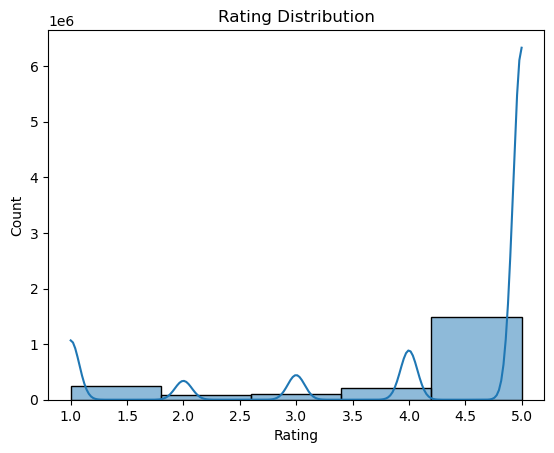

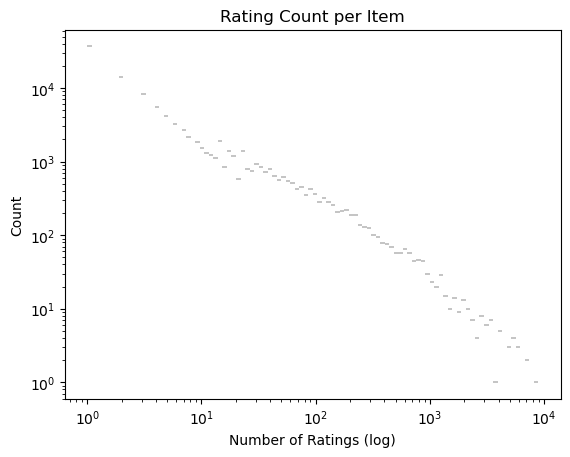

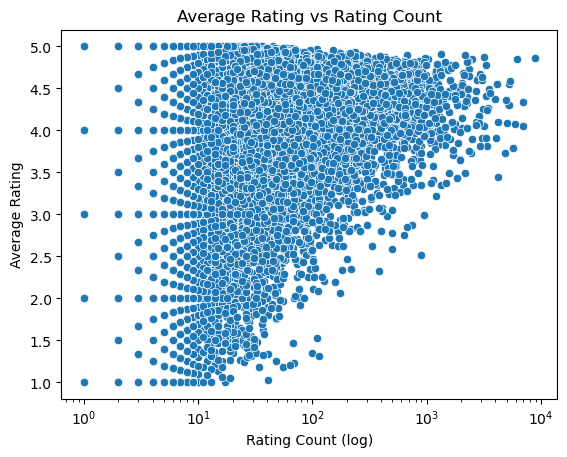

In [7]:
# Ratings distribution
sns.histplot(df['rating'], bins=5, kde=True)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Rating count per item
rating_counts = df.groupby('asin')['rating'].count().sort_values(ascending=False)
sns.histplot(rating_counts, bins=100, log_scale=(True, True))
plt.title('Rating Count per Item')
plt.xlabel('Number of Ratings (log)')
plt.show()

# Relationship: rating_count vs. average_rating
avg_rating_per_item = df.groupby('asin')['rating'].mean()
merged_stats = pd.DataFrame({
    'average_rating': avg_rating_per_item,
    'rating_count': rating_counts
}).dropna()

sns.scatterplot(data=merged_stats, x='rating_count', y='average_rating')
plt.xscale('log')
plt.title('Average Rating vs Rating Count')
plt.xlabel('Rating Count (log)')
plt.ylabel('Average Rating')
plt.show()


## 3. Time-Based Trends

In [8]:
df.columns

Index(['rating', 'title_x', 'text', 'images_x', 'asin', 'parent_asin',
       'user_id', 'timestamp', 'helpful_vote', 'verified_purchase',
       'main_category', 'title_y', 'average_rating', 'rating_number',
       'features', 'description', 'price', 'images_y', 'videos', 'store',
       'categories', 'details', 'bought_together', 'subtitle', 'author',
       'date'],
      dtype='object')

<Axes: title={'center': 'Reviews Over Time'}, xlabel='timestamp'>

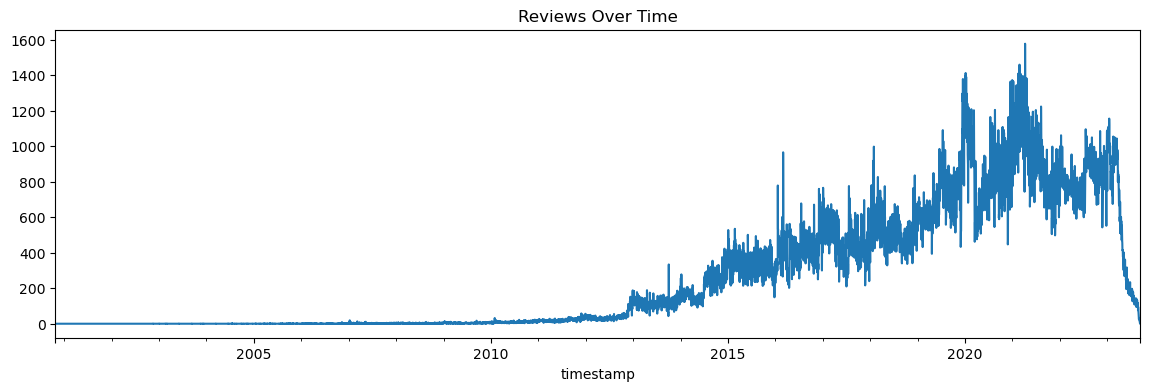

In [9]:
# Total reviews over time
df.set_index('timestamp', inplace=True)
df['rating'].resample('D').count().plot(figsize=(14, 4), title='Reviews Over Time')

In [10]:
# 3-day rolling avg rating
df['rolling_avg'] = df['rating'].rolling(window=3).mean()
df['rolling_avg'].plot(figsize=(14, 4), title='3-Day Rolling Average Rating')

<Axes: title={'center': '3-Day Rolling Average Rating'}, xlabel='timestamp'>

Error in callback <function _draw_all_if_interactive at 0x0000027D665055E0> (for post_execute), with arguments args (),kwargs {}:


OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 1400x400 with 1 Axes>

<Axes: title={'center': 'Weekly % of Positive Reviews'}, xlabel='timestamp'>

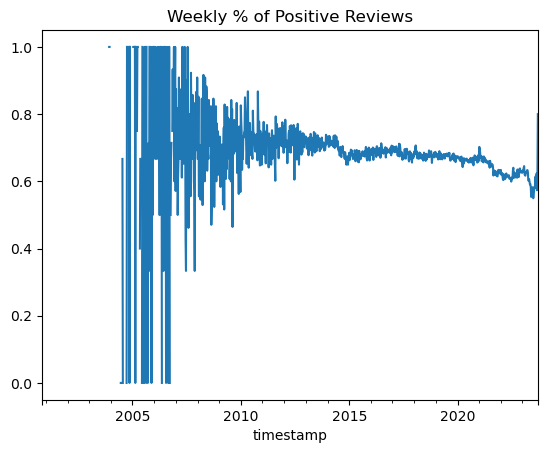

In [11]:

# Weekly positivity trend (sentiment-based)
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['positive'] = df['sentiment'] > 0.3
weekly_positive = df.resample('W')['positive'].mean()
weekly_positive.plot(title='Weekly % of Positive Reviews')


## 4. Textual Review Analysis

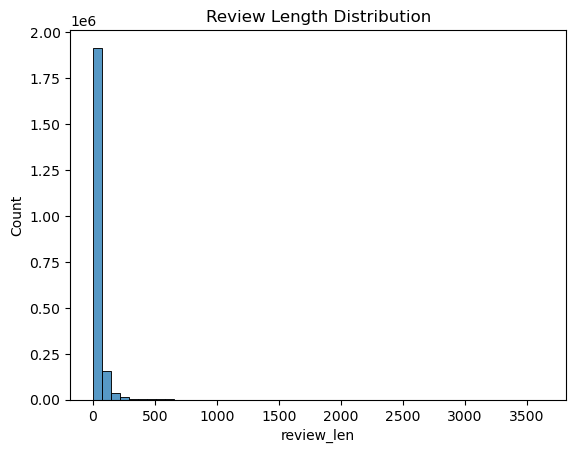

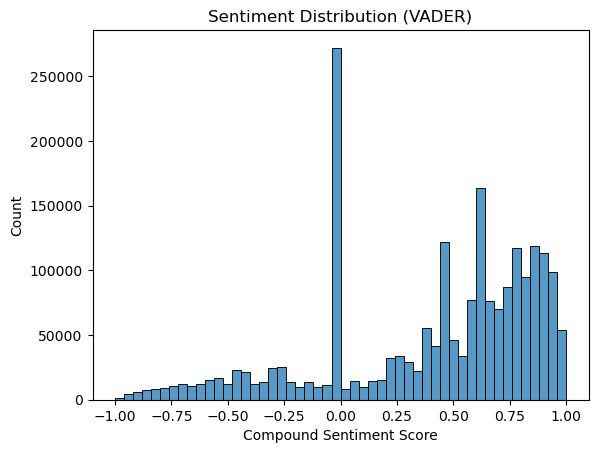

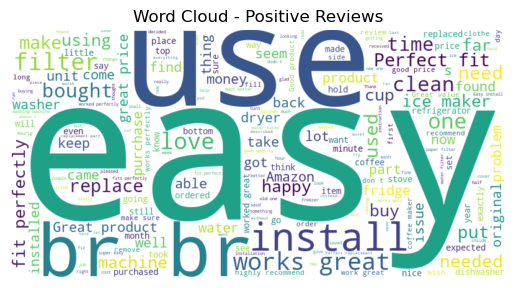

In [12]:
# Review length
df['review_len'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['review_len'], bins=50)
plt.title('Review Length Distribution')
plt.show()

# Sentiment distribution
sns.histplot(df['sentiment'], bins=50)
plt.title('Sentiment Distribution (VADER)')
plt.xlabel('Compound Sentiment Score')
plt.show()

# Word cloud for positive reviews
positive_reviews = ' '.join(df[df['positive']]['text'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')
plt.show()


### 5. Metadata EDA

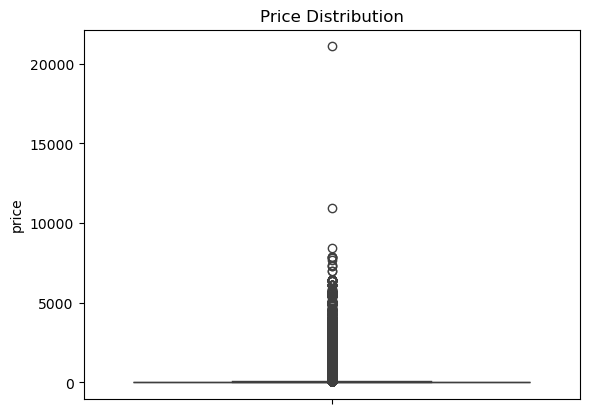

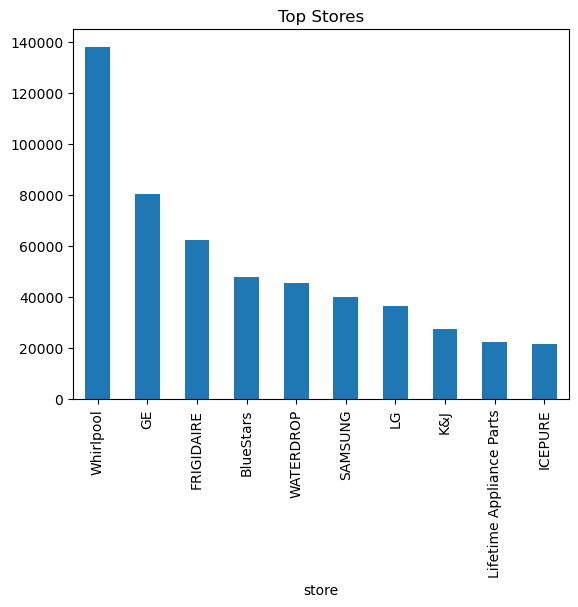

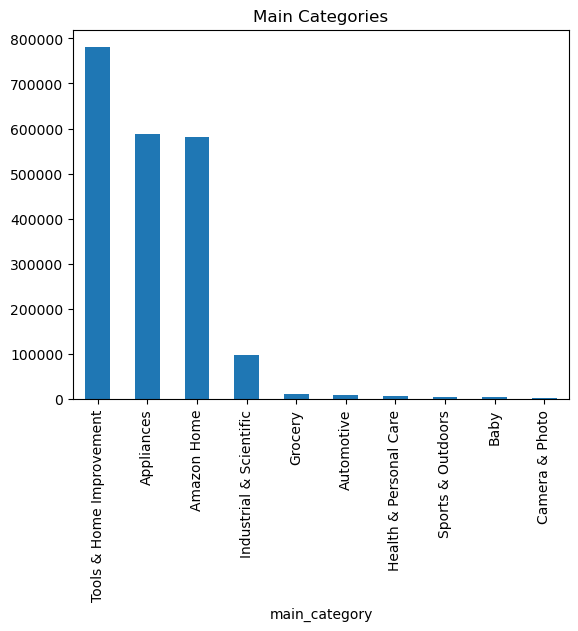

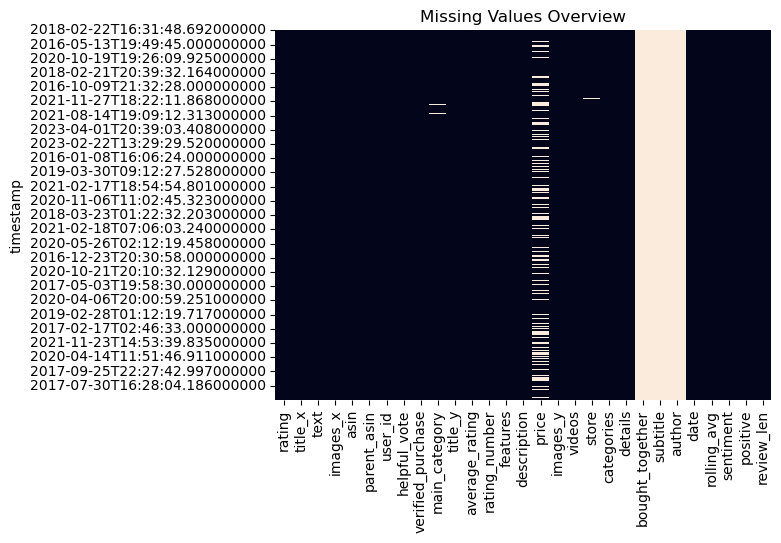

In [13]:
# Price distribution
df['price'] = pd.to_numeric(df['price'], errors='coerce')
sns.boxplot(df['price'])
plt.title('Price Distribution')
plt.show()

# Top brands/stores
df['store'].value_counts().head(10).plot(kind='bar', title='Top Stores')
plt.show()

# Category breakdown (if categorical)
df['main_category'].value_counts().head(10).plot(kind='bar', title='Main Categories')
plt.show()

# Missing value heatmap
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Overview')
plt.show()


### 6. Embedding Prep for Two-Tower

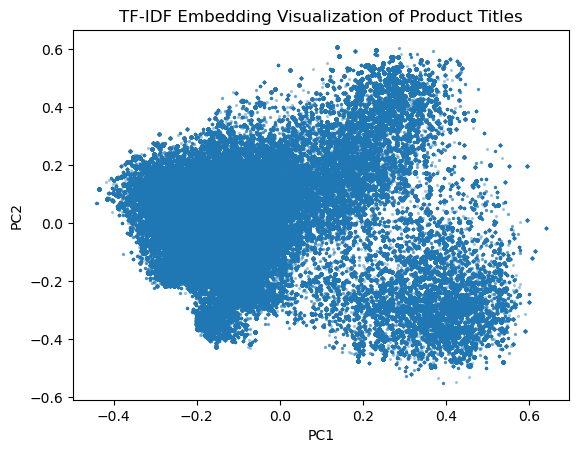

In [14]:
# Vectorize item titles
tfidf = TfidfVectorizer(max_features=100)
X = tfidf.fit_transform(df['title_y'].dropna().astype(str))

# PCA to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

# Plot
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.3, s=2)
plt.title('TF-IDF Embedding Visualization of Product Titles')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [2]:
import pandas as pd 
df = pd.read_csv('./Data/user_embeddings.csv', index_col=0)
df.head()
# Convert dataframes to dictionaries
user_embeddings_dict = df.apply(lambda row: row.tolist(), axis=1).to_dict()

user_embeddings_dict

{'AE222FP7YRNFCEQ2W3ZDIGMSYTLQ': [-0.006299503,
  0.03600143,
  -0.059657443,
  0.040621057,
  -0.010503091,
  -0.036211926,
  -0.03658642,
  0.18238825,
  0.0366318,
  -0.024315659,
  0.011220198,
  0.007393807,
  -0.0063858107,
  -0.05228548,
  0.7772686,
  0.44282365,
  -0.008352011,
  -0.13416421,
  -0.7226019,
  0.26150316,
  0.012937427,
  0.09670348,
  0.04976099,
  0.012763035,
  0.07039899,
  0.16555071,
  0.012863576,
  -0.046044417,
  -0.013475303,
  -0.014655806,
  -0.032395434,
  -0.6774067,
  0.2611911,
  -0.064382516,
  0.05988179,
  0.07373006,
  0.03163755,
  0.002178058,
  -0.33443174,
  0.28804672,
  0.03908822,
  -0.033305965,
  -0.6573675,
  -0.04325504,
  0.12251139,
  -0.14678593,
  -0.039614674,
  -0.07073625,
  -0.013051499,
  -0.049036726,
  -0.4966026,
  -0.48877212,
  -0.09024531,
  0.044280183,
  -0.04355049,
  -0.10494617,
  0.43371788,
  -0.08158465,
  0.13696937,
  0.82330626,
  1.155246,
  -0.6707313,
  -0.035386276,
  -0.23019359,
  -0.0706912,
  0.016

In [4]:
df = pd.read_csv('./Data/user_embeddings.csv')
df.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,AE222FP7YRNFCEQ2W3ZDIGMSYTLQ,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
1,AE223N4K4ROAGJPN55UM3IYGGCOQ,-0.002614,-0.075165,0.047873,-0.058270,0.028321,0.075691,0.018950,0.234011,-0.059246,...,-0.050144,0.068293,0.045675,-0.086957,-0.020765,-0.117614,0.038933,0.072390,0.073911,-0.309598
2,AE225KTEK4YRJE2TBGPJZEAXAA4Q,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
3,AE225NQR6TN6SUNMTF6O4T37TXPQ,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
4,AE225T2ZALMW2LGAWZGONMYD2VJA,-0.011199,-0.064673,0.033208,-0.031332,0.020692,0.073850,-0.003049,0.250044,-0.043496,...,-0.033677,0.059353,0.024668,-0.062254,-0.008719,-0.078117,0.030568,0.065703,0.053348,-0.318912


In [3]:
import json
with open('./Data/user_embeddings.json', 'r') as f:
    user_emb = json.load(f)
user_emb

{'AE222FP7YRNFCEQ2W3ZDIGMSYTLQ': [-0.006299503,
  0.03600143,
  -0.059657443,
  0.040621057,
  -0.010503091,
  -0.036211926,
  -0.03658642,
  0.18238825,
  0.0366318,
  -0.024315659,
  0.011220198,
  0.007393807,
  -0.0063858107,
  -0.05228548,
  0.7772686,
  0.44282365,
  -0.008352011,
  -0.13416421,
  -0.7226019,
  0.26150316,
  0.012937427,
  0.09670348,
  0.04976099,
  0.012763035,
  0.07039899,
  0.16555071,
  0.012863576,
  -0.046044417,
  -0.013475303,
  -0.014655806,
  -0.032395434,
  -0.6774067,
  0.2611911,
  -0.064382516,
  0.05988179,
  0.07373006,
  0.03163755,
  0.002178058,
  -0.33443174,
  0.28804672,
  0.03908822,
  -0.033305965,
  -0.6573675,
  -0.04325504,
  0.12251139,
  -0.14678593,
  -0.039614674,
  -0.07073625,
  -0.013051499,
  -0.049036726,
  -0.4966026,
  -0.48877212,
  -0.09024531,
  0.044280183,
  -0.04355049,
  -0.10494617,
  0.43371788,
  -0.08158465,
  0.13696937,
  0.82330626,
  1.155246,
  -0.6707313,
  -0.035386276,
  -0.23019359,
  -0.0706912,
  0.016